In [2]:
import pandas as pd 
import matplotlib.pyplot as plt 
import ast
import numpy as np 
import seaborn as sns
from adjustText import adjust_text



dataset = pd.read_csv('/Users/tajveer/Downloads/data_jobs.csv')
df = pd.DataFrame(dataset)
df['job_posted_date']= pd.to_datetime(df['job_posted_date'])

df['job_skills'] = df['job_skills'].apply(lambda skill_list: ast.literal_eval(skill_list)if pd.notna(skill_list) else skill_list)
df['job_posted_date']= pd.to_datetime(df['job_posted_date'])


In [3]:
df_US = df[(df['job_country']== 'United States')& (df['job_title_short']== 'Data Analyst')].copy()

In [4]:
df_US = df_US.dropna(subset=['salary_year_avg'])
df_US_exploded = df_US.explode('job_skills')
df_DA_skills= df_US_exploded[['salary_year_avg', 'job_skills']]
df_DA_skills= df_US_exploded.groupby('job_skills')['salary_year_avg'].agg(['count', 'median']).sort_values(by= 'count', ascending=False)
DA_job_count= len(df_US)
df_DA_skills['skill_percentage']= df_DA_skills['count']/ DA_job_count*100
df_DA_skills
skill_percent = 5
df_DA_skill_in_demand = df_DA_skills[df_DA_skills['skill_percentage']>skill_percent]




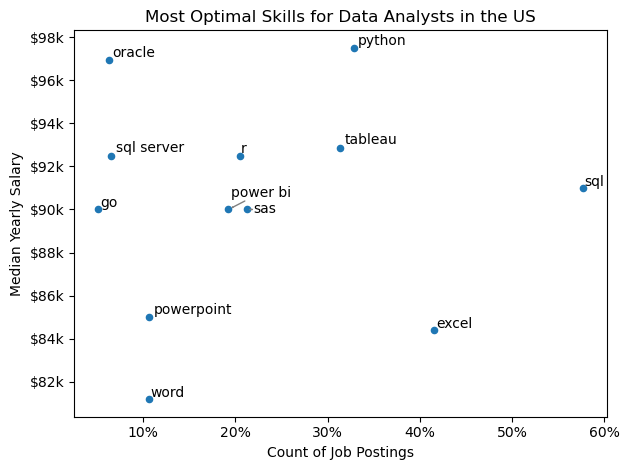

In [5]:
df_DA_skill_in_demand.plot(kind= 'scatter', x= 'skill_percentage', y = 'median')

texts =[]
for i, txt in enumerate(df_DA_skill_in_demand.index):
    texts.append(plt.text(df_DA_skill_in_demand['skill_percentage'].iloc[i],df_DA_skill_in_demand['median'].iloc[i], txt))

from matplotlib.ticker import PercentFormatter
adjust_text(texts, arrowprops = dict (arrowstyle= '->', color='gray', lw= 1))
ax = plt.gca()
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, pos: f'${int (y/1000)}k'))
ax.xaxis.set_major_formatter(PercentFormatter(decimals=0))
plt.xlabel('Count of Job Postings')
plt.ylabel('Median Yearly Salary')
plt.title('Most Optimal Skills for Data Analysts in the US')
plt.tight_layout()
plt.show()

In [6]:
df_technology = df['job_type_skills'].copy()

# remove duplicates
df_technology = df_technology.drop_duplicates()

# remove NaN values
df_technology = df_technology.dropna()

# combine all dictionaries into one
technology_dict = {}
for row in df_technology:
    row_dict = ast.literal_eval(row)  # convert string to dictionary
    for key, value in row_dict.items():
        if key in technology_dict:  # if key already exists in technology_dict, add value to existing value
            technology_dict[key] += value
        else:                       # if key does not exist in technology_dict, add key and value
            technology_dict[key] = value

# remove duplicates by converting values to set then back to list
for key, value in technology_dict.items():
    technology_dict[key] = list(set(value))

technology_dict

{'analyst_tools': ['tableau',
  'looker',
  'outlook',
  'dax',
  'microstrategy',
  'sharepoint',
  'splunk',
  'spreadsheet',
  'alteryx',
  'datarobot',
  'word',
  'spss',
  'ssrs',
  'ms access',
  'powerpoint',
  'visio',
  'powerbi',
  'ssis',
  'qlik',
  'sheets',
  'nuix',
  'esquisse',
  'msaccess',
  'sas',
  'cognos',
  'power bi',
  'sap',
  'excel'],
 'programming': ['mongodb',
  'fortran',
  'f#',
  't-sql',
  'c++',
  'shell',
  'pascal',
  'perl',
  'no-sql',
  'go',
  'vba',
  'r',
  'golang',
  'python',
  'java',
  'php',
  'css',
  'mongo',
  'typescript',
  'crystal',
  'dart',
  'apl',
  'javascript',
  'rust',
  'lisp',
  'vb.net',
  'delphi',
  'nosql',
  'haskell',
  'julia',
  'sass',
  'ocaml',
  'powershell',
  'objective-c',
  'kotlin',
  'swift',
  'assembly',
  'c#',
  'erlang',
  'html',
  'cobol',
  'lua',
  'bash',
  'solidity',
  'visualbasic',
  'sas',
  'matlab',
  'c',
  'ruby',
  'clojure',
  'sql',
  'scala',
  'visual basic',
  'elixir',
  'gro

In [15]:
df_technology= pd.DataFrame(list(technology_dict.items()), columns=['technology', 'skills'])
df_technology =df_technology.explode('skills')
df_technology

,technology,skills
0,analyst_tools,tableau
0,analyst_tools,looker
0,analyst_tools,outlook
0,analyst_tools,dax
0,analyst_tools,microstrategy
...,...,...
9,sync,wire
9,sync,zoom
9,sync,google chat
9,sync,symphony


In [30]:
# merge df_DA_skills and df_technology
df_DA_skills_tech = df_DA_skills.merge(df_technology, left_on='job_skills', right_on='skills')
df_DA_skills_tech_high_demand = df_DA_skills_tech[df_DA_skills_tech['skill_percentage'] > skill_percent]
df_DA_skills_tech

,count,median,skill_percentage,technology,skills
0,2508,91000.0,57.655172,programming,sql
1,1808,84392.0,41.563218,analyst_tools,excel
2,1431,97500.0,32.896552,programming,python
3,1364,92875.0,31.356322,analyst_tools,tableau
4,926,90000.0,21.287356,analyst_tools,sas
...,...,...,...,...,...
169,1,160515.0,0.022989,databases,couchbase
170,1,100000.0,0.022989,libraries,chainer
171,1,85000.0,0.022989,other,chef
172,1,113269.5,0.022989,libraries,cordova


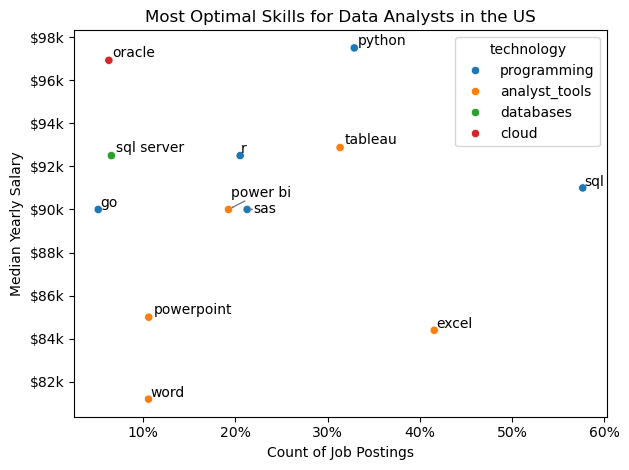

In [32]:
# df_DA_skill_in_demand.plot(kind= 'scatter', x= 'skill_percentage', y = 'median')
sns.scatterplot(
    data= df_DA_skills_tech_high_demand,
    x='skill_percentage',
    y='median',
    hue= 'technology'
)
texts =[]
for i, txt in enumerate(df_DA_skill_in_demand.index):
    texts.append(plt.text(df_DA_skill_in_demand
['skill_percentage'].iloc[i],df_DA_skill_in_demand
['median'].iloc[i], txt))

from matplotlib.ticker import PercentFormatter
adjust_text(texts, arrowprops = dict (arrowstyle= '->', color='gray', lw= 1))
ax = plt.gca()
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, pos: f'${int (y/1000)}k'))
ax.xaxis.set_major_formatter(PercentFormatter(decimals=0))
plt.xlabel('Count of Job Postings')
plt.ylabel('Median Yearly Salary')
plt.title('Most Optimal Skills for Data Analysts in the US')
plt.tight_layout()
plt.show()